In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

In [2]:
# ── nice print helper ──────────────────────────────────────────────────────────
SEP  = "=" * 60
sep  = "-" * 60
 
def section(title):
    print(f"\n{SEP}\n  {title}\n{SEP}")

## STEP 1 - LOAD THE DATA

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 ─ LOAD THE DATA
# Why: Before touching anything, we need to confirm the files load correctly
#      and see their raw shape (rows × columns).
# ══════════════════════════════════════════════════════════════════════════════

section("STEP 1 · Load the data")
 
products = pd.read_csv("../ML-TASK/products.csv")
outfits  = pd.read_csv("../ML-TASK/outfits.csv")



  STEP 1 · Load the data


In [4]:
products.drop(columns=["collected_at"], inplace=True)
products["brand"] = products["brand"].str.upper()

In [5]:
print(f"products.csv  →  {products.shape[0]} rows  ×  {products.shape[1]} columns")
print(f"outfits.csv   →  {outfits.shape[0]} rows  ×  {outfits.shape[1]} columns")
print("\nProduct columns :")

Product_data_Columns  = pd.DataFrame({"Columns":products.columns})
Product_data_Columns

products.csv  →  68 rows  ×  17 columns
outfits.csv   →  25 rows  ×  22 columns

Product columns :


,Columns
0,id
1,name
2,brand
3,price_inr
4,rating
5,rating_count
6,gender
7,wear_type
8,category
9,category_label


In [6]:
print("\nOutfit  columns :")
Outfit_data_Columns = pd.DataFrame({"Columns":outfits.columns})
Outfit_data_Columns


Outfit  columns :


,Columns
0,outfit_id
1,gender
2,wear_type
3,occasion
4,theme
5,hero
6,hero_id
7,second
8,second_id
9,layer


## STEP 2 . Peek at the First Rows

In [7]:
products.head(3)

,id,name,brand,price_inr,rating,rating_count,gender,wear_type,category,category_label,occasion,tags,description,description_source,image,site,product_url
0,myntra_28569210,Cotton Slim Fit Formal Shirt,ARROW,1099,4.5,69.0,men,western,formal-shirts,Formal Shirts,office,men;western;formal-shirts;office;Arrow,"White solid opaque Formal shirt ,has a cutaway...",site,images/myntra/28569210.jpg,myntra,https://www.myntra.com/shirts/arrow/arrow-cott...
1,ajio_469618352,Men Regular Fit 2-Piece Suit Set,ARROW,5000,3.3,NaN,men,western,suits,Suits,wedding,men;western;suits;wedding;ARROW,Grey suit for men from ARROW. It features a re...,metadata,images/ajio/469618352.jpg,ajio,https://www.ajio.com/arrow-men-regular-fit-2-p...
2,ajio_443087217,Men Oversized Fit Crew-Neck Sweatshirt,DNMX,300,4.0,NaN,men,western,sweatshirts,Sweatshirts,casual,men;western;sweatshirts;casual;DNMX,Dark grey sweatshirt for men from DNMX. It fea...,metadata,images/ajio/443087217.jpg,ajio,https://www.ajio.com/dnmx-men-oversized-fit-cr...


In [8]:
outfits.head(3)

,outfit_id,gender,wear_type,occasion,theme,hero,hero_id,second,second_id,layer,...,footwear_id,accessory_1,accessory_1_id,accessory_2,accessory_2_id,palette,items_count,total_price_inr,image_files,stylist_rationale
0,outfit W1,women,western,party,Black cocktail,Women Bodycon Midi Length Dress (Fyre Rose),ajio_703182002,NaN,NaN,NaN,...,myntra_42540276,Sparkle Framed Clutch (Lavie),myntra_15660676,NaN,NaN,black / red,3,2313,images/ajio/703182002.jpg;images/myntra/425402...,Black midi with a gold chain waist detail; gol...
1,outfit W2,women,western,party,Wine bodycon evening,Bodycon Midi Dress (MULVARI),myntra_41733768,NaN,NaN,NaN,...,myntra_31751105,Women Embellished Clutch with Lock (Rubans),ajio_701677398,NaN,NaN,maroon / red / white,3,1977,images/myntra/41733768.jpg;images/myntra/31751...,Sleek wine square-neck bodycon; nude-tan kitte...
2,outfit W3,women,western,party,"Magenta slip, night out",Ruched Asymmetrical Midi Dress (MANGO),myntra_34682942,NaN,NaN,NaN,...,myntra_32069236,Sling Bag with Quilted (Exotic),myntra_24130018,NaN,NaN,red / white / black,3,3870,images/myntra/34682942.jpg;images/myntra/32069...,Magenta ruched slip dress with white pointed a...


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 ─ DATA TYPES & BASIC STATS
# Why: We need to know which columns are numbers vs text.
#      Numbers get statistics (mean, min, max). Text columns get value counts.
# ══════════════════════════════════════════════════════════════════════════════
section("STEP 3 · Data types & basic statistics")
print("\n── products dtypes ──")
print(products.dtypes)


  STEP 3 · Data types & basic statistics

── products dtypes ──
id                        str
name                      str
brand                     str
price_inr               int64
rating                float64
rating_count          float64
gender                    str
wear_type                 str
category                  str
category_label            str
occasion                  str
tags                      str
description               str
description_source        str
image                     str
site                      str
product_url               str
dtype: object


In [10]:
products["brand"].unique()

<ArrowStringArray>
[                     'ARROW',                       'DNMX',
               'JACK & JONES',                   'NEONOMAD',
                      'KISAH',                  'FYRE ROSE',
                 'STYLEELITE',                     'NYRIKA',
                       'PUMA', 'FOREVER GLAM BY PANTALOONS',
                        'DFR',                   'VATSALYA',
                     'ALDENO',              'INSTAFAB PLUS',
                       'RIGO',                       'XYXX',
                    'RAYMOND',               'AD BY ARVIND',
           'THE SOULED STORE',                   'DAMENSCH',
                 'VAN HEUSEN',                  'VERO MODA',
           'HOUSE OF PATAUDI',                   'FABINDIA',
                      'MANGO',      'U.S. POLO ASSN. WOMEN',
                 'POWERSUTRA',                      'KOTTY',
                     'HUNNIT',             'BONKERS CORNER',
                   'ROADSTER',               'ANOUK MIRAGE',
     

In [11]:
print("\n── numeric summary (products) ──")
products.describe().round(2)


── numeric summary (products) ──

,price_inr,rating,rating_count
count,68.00,43.00,26.00
mean,1518.13,3.92,121.08
std,1469.65,0.92,229.59
min,270.00,1.00,1.00
25%,732.25,3.55,5.25
50%,1082.00,4.10,21.00
75%,1596.00,4.50,89.25
max,7799.00,5.00,949.00


## STEP 4 - MISSING VALUES

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 ─ MISSING VALUES
# Why: Missing data breaks models. We need to know exactly where the holes are
#      before we start building anything.
# ══════════════════════════════════════════════════════════════════════════════

p_miss = products.isnull().sum()
p_miss_pct = (p_miss / len(products) * 100).round(1)

miss_df = pd.DataFrame({
    "missing": p_miss,
    "missing_pct": p_miss_pct
})

missing_summary = miss_df[miss_df["missing"] > 0]

missing_summary

,missing,missing_pct
rating,25,36.8
rating_count,42,61.8


In [13]:
print("\n── outfits ── (count  |  % of total)")

o_miss = outfits.isnull().sum()
o_miss_pct = (o_miss / len(outfits) * 100).round(1)

miss_df2 = pd.DataFrame({
    "missing": o_miss,
    "%": o_miss_pct
})

# keep only columns with missing values
result_df = miss_df2[miss_df2["missing"] > 0]

# ensure output is always a DataFrame
result_df


── outfits ── (count  |  % of total)


,missing,%
second,12,48.0
second_id,12,48.0
layer,21,84.0
layer_id,21,84.0
accessory_1,3,12.0
accessory_1_id,3,12.0
accessory_2,21,84.0
accessory_2_id,21,84.0



  STEP 5 · Categorical distributions


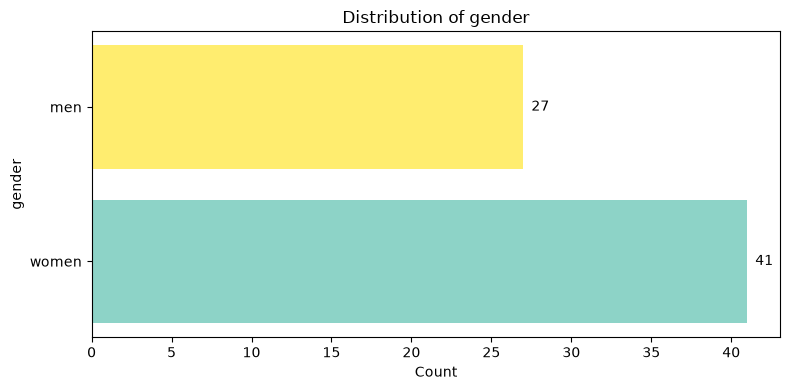

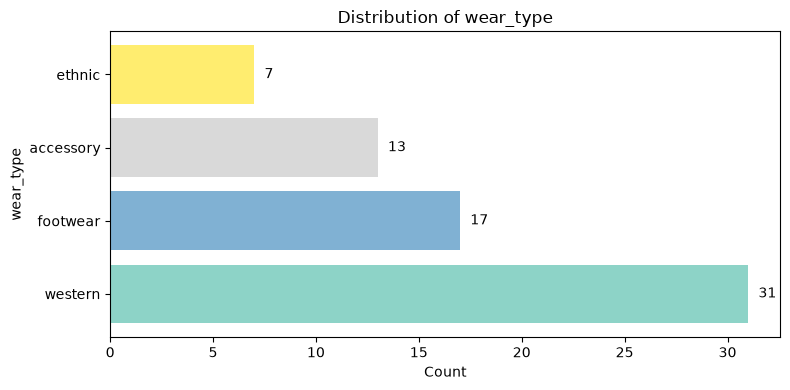

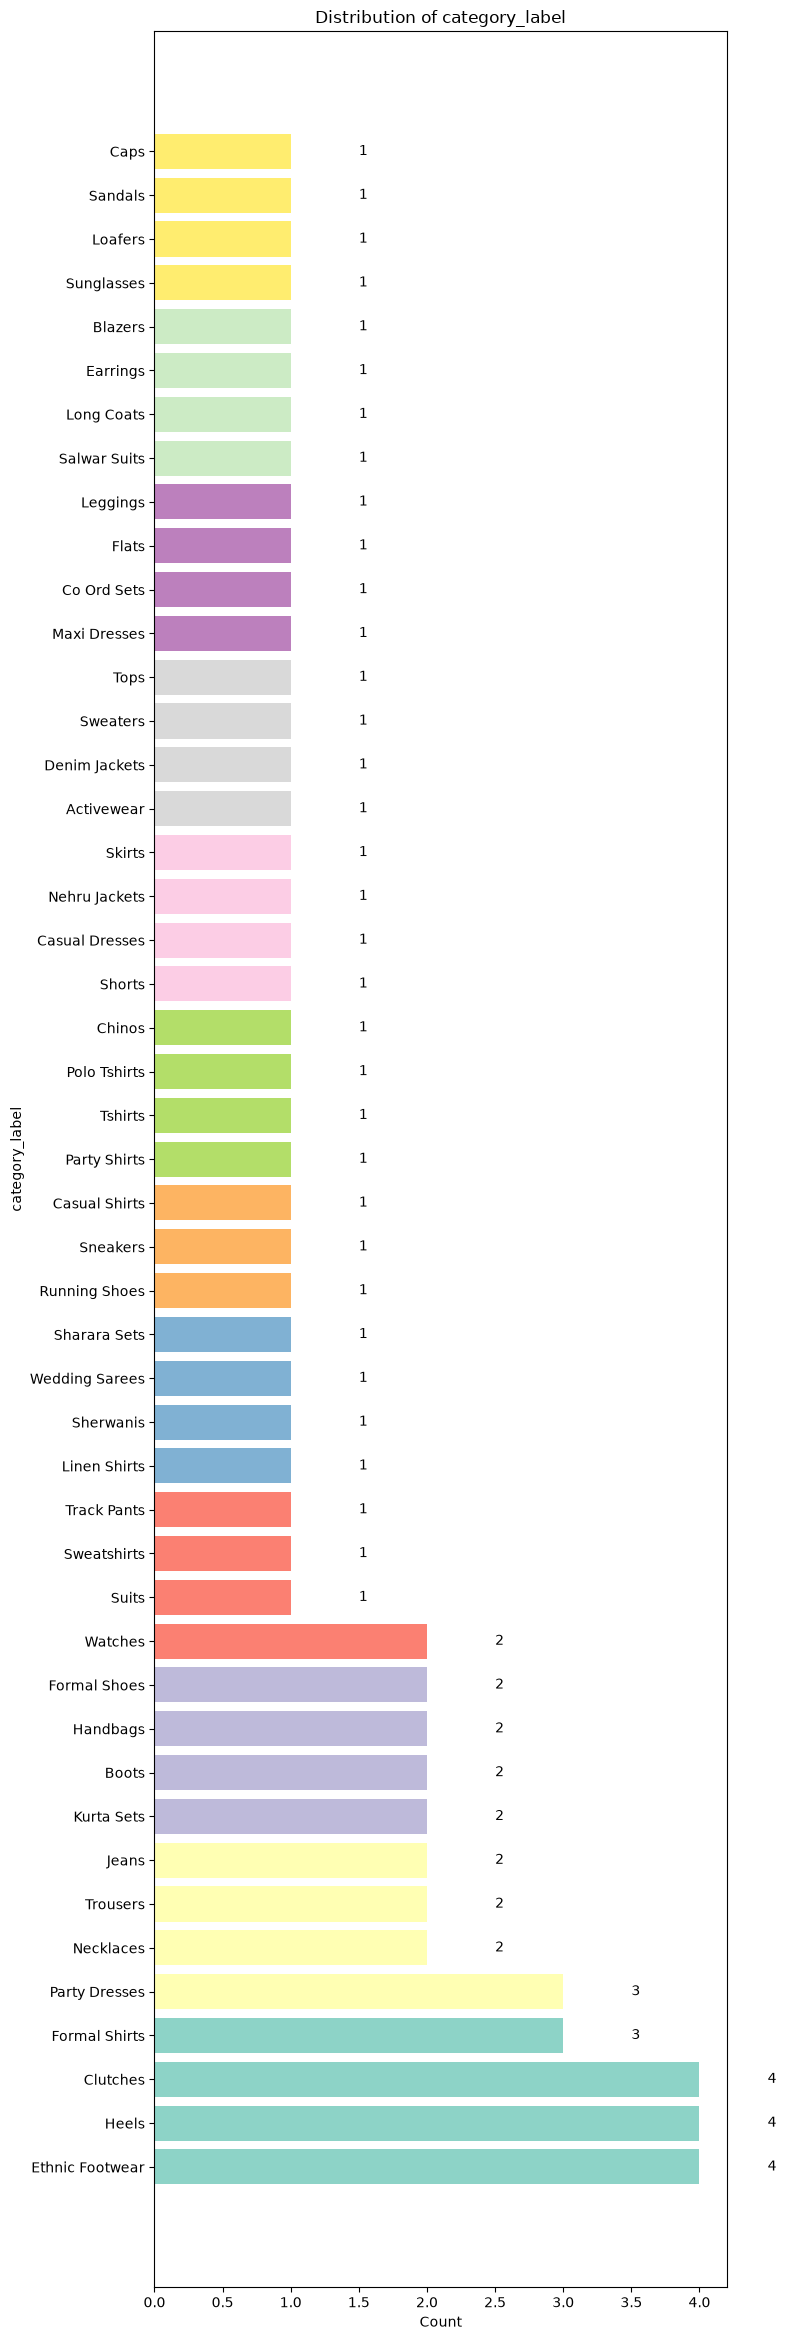

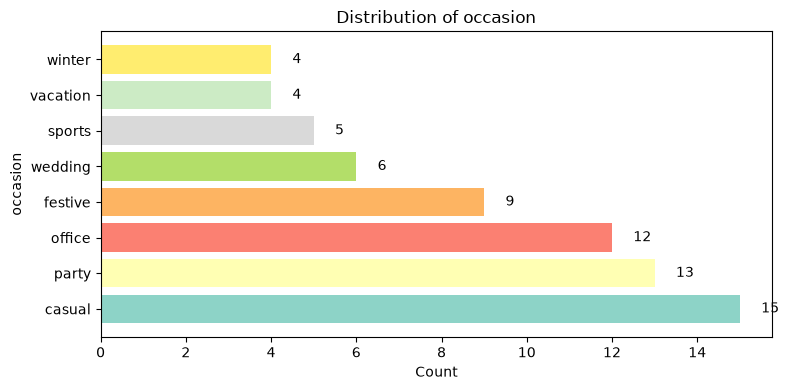

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 ─ UNIQUE VALUE COUNTS (CATEGORICAL COLUMNS)
# Why: For columns like gender/occasion/category, we want to know exactly which
#      values exist and how many items fall into each bucket. This reveals
#      data imbalances — e.g. "are there far more women's items than men's?"
# ══════════════════════════════════════════════════════════════════════════════
section("STEP 5 · Categorical distributions")
 
cat_cols = ["gender", "wear_type", "category_label", "occasion"]

for col in cat_cols:
    if col in products.columns:

        vc = products[col].value_counts()

        plt.figure(figsize=(8, max(4, len(vc) * 0.5)))

        # Generate different colors
        colors = plt.cm.Set3(np.linspace(0, 1, len(vc)))

        bars = plt.barh(
            vc.index.astype(str),
            vc.values,
            color=colors
        )

        plt.title(f"Distribution of {col}")
        plt.xlabel("Count")
        plt.ylabel(col)

        # Add value annotations
        for bar in bars:
            width = bar.get_width()
            plt.text(
                width + 0.5,
                bar.get_y() + bar.get_height()/2,
                f"{int(width)}",
                va="center"
            )

        plt.tight_layout()
        plt.show()

In [15]:
# STEP 6 ─ PRICE ANALYSIS
# Why: Price range tells us the quality tier of the dataset.
#      We look for outliers (₹5 item? ₹50,000 item?) that may be data errors.
#      Price also matters for recommendations — don't pair a ₹500 shirt
#      with a ₹20,000 blazer.

if "price_inr" in products.columns:
    prices = products["price_inr"].dropna()
    print(f"  Min price  : ₹{prices.min():,.0f}")
    print(f"  Max price  : ₹{prices.max():,.0f}")
    print(f"  Mean price : ₹{prices.mean():,.0f}")
    print(f"  Median     : ₹{prices.median():,.0f}")
    print(f"\n  Price by category:")
    print(products.groupby("category_label")["price_inr"]
          .agg(["mean","min","max"]).round(0).sort_values("mean", ascending=False))
# --- ADVANCED IQR PRICE OUTLIER DETECTION ---
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = prices[(prices < lower_bound) | (prices > upper_bound)]
print(f"\n  IQR Pricing Outliers (Boundaries: {lower_bound:,.0f} to {upper_bound:,.0f}):")
print(f"  Found {len(outliers)} outliers in pricing distribution.")
if len(outliers) > 0:
    print(products[products["price_inr"].isin(outliers)][["name", "price_inr", "brand"]].to_string(index=False))


  Min price  : ₹270
  Max price  : ₹7,799
  Mean price : ₹1,518
  Median     : ₹1,082

  Price by category:
                   mean   min   max
category_label                     
Sherwanis        7799.0  7799  7799
Suits            5000.0  5000  5000
Watches          4966.0  2236  7697
Casual Dresses   4550.0  4550  4550
Long Coats       4000.0  4000  4000
Co Ord Sets      3104.0  3104  3104
Formal Shoes     2745.0  1500  3990
Running Shoes    2535.0  2535  2535
Blazers          2369.0  2369  2369
Denim Jackets    2253.0  2253  2253
Loafers          1610.0  1610  1610
Salwar Suits     1599.0  1599  1599
Jeans            1588.0  1350  1826
Trousers         1572.0  1224  1920
Ethnic Footwear  1517.0   768  2699
Chinos           1500.0  1500  1500
Sharara Sets     1300.0  1300  1300
Party Dresses    1251.0   590  2397
Leggings         1229.0  1229  1229
Handbags         1222.0   849  1595
Nehru Jackets    1199.0  1199  1199
Activewear       1155.0  1155  1155
Kurta Sets       1136.0   94

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 ─ RATING ANALYSIS
# Why: High-rated items make better recommendations. Low-rated items should
#      maybe be excluded. Also checks if rating_count is large enough to trust.
# ══════════════════════════════════════════════════════════════════════════════
section("STEP 7 · Rating analysis")
 
if "rating" in products.columns:
    print(products[["rating"]].describe().round(2))
    low_rated = products[products["rating"] < 3.5][["name","rating"]]
    print(f"\n  Items with rating < 3.5:  {len(low_rated)}")
    if len(low_rated):
        print(low_rated.to_string(index=False))
# --- RATING COUNT DISTRIBUTION ANALYSIS ---
if "rating_count" in products.columns:
    print("\n  Rating Count Distribution:")
    print(products["rating_count"].describe().round(1))



  STEP 7 · Rating analysis
       rating
count   43.00
mean     3.92
std      0.92
min      1.00
25%      3.55
50%      4.10
75%      4.50
max      5.00

  Items with rating < 3.5:  10
                                                            name  rating
                                Men Regular Fit 2-Piece Suit Set     3.3
Men Texture Solid Indowestern Sherwani Churidar with Dupatta Set     3.4
                          Women Floral Woven Banarasi Silk Saree     2.9
                         Men Softride Carson Fresh Running Shoes     2.5
                     Women Stone-Studded Necklace & Earrings Set     3.3
                       Women Floral Print Maxi Fit & Flare Dress     1.0
                                      Women Slip-On Flat Sandals     3.4
                       Women Embellished Anarkali Kurta Suit Set     1.0
                                   Men Patterned Low-Top Loafers     3.4
            Men Elevator Casual Heeled Slip-on Traditional Jutti     2.0

  Rating C

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 ─ OUTFIT COVERAGE CHECK
# Why: Are all 68 products actually used in the 25 curated outfits?
#      Unused products won't appear in recommendations from the curated set.
#      This tells us the gap between curated ground-truth and full catalog.
# ══════════════════════════════════════════════════════════════════════════════
section("STEP 8 · Outfit coverage — which products are used?")


  STEP 8 · Outfit coverage — which products are used?


In [18]:
id_cols = [c for c in outfits.columns if c.endswith("_id")]
all_used_ids = pd.Series(
    [v for col in id_cols for v in outfits[col].dropna().tolist()]
).unique()
all_product_ids = products["id"].unique()
covered = set(all_used_ids) & set(all_product_ids)
uncovered = set(all_product_ids) - covered

print(f"  Total products      : {len(all_product_ids)}")
print(f"  Used in outfits     : {len(covered)}")
print(f"  NOT used in outfits : {len(uncovered)}")

if uncovered:
    print("\n  Unused product IDs:")
    for pid in sorted(uncovered):
        row = products[products["id"] == pid]
        if len(row):
            print(f"    {pid}  →  {row.iloc[0]['name']}")

  Total products      : 68
  Used in outfits     : 68
  NOT used in outfits : 0



  STEP 9 · Outfit variety check


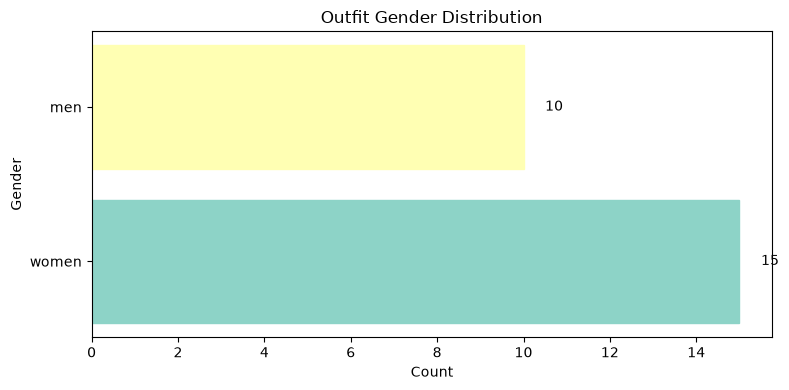

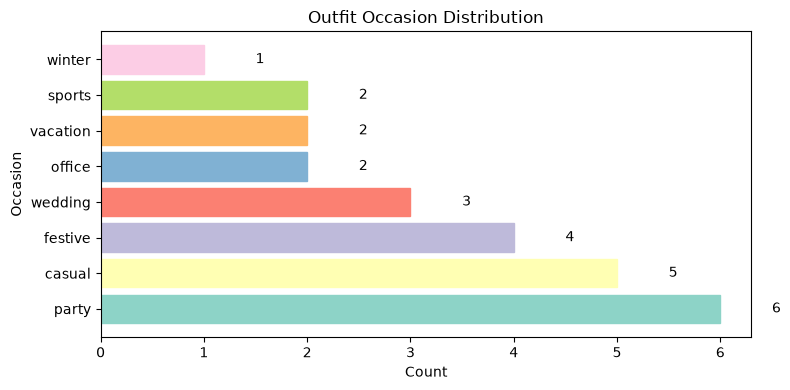

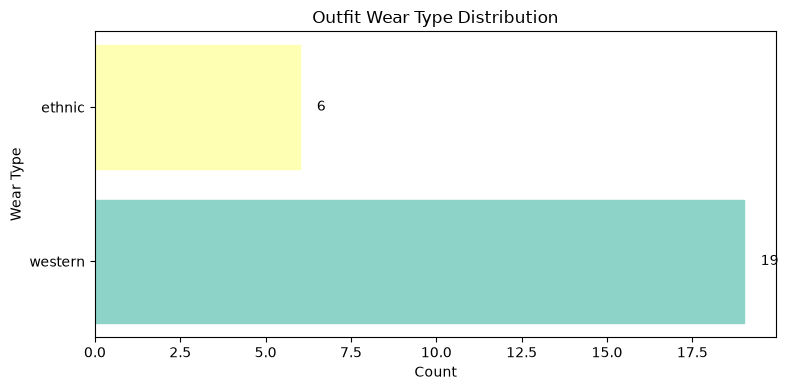

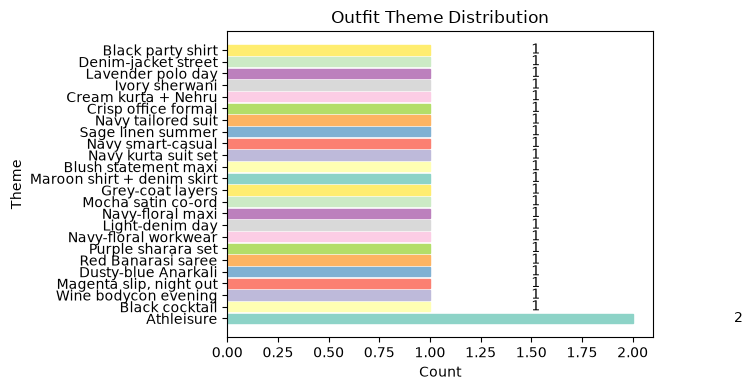

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 ─ OUTFIT OCCASION / THEME DISTRIBUTION
# Why: Checks if the 25 curated outfits cover enough variety.
#      If 20 of 25 are "casual", the engine will struggle with formal requests.
# ══════════════════════════════════════════════════════════════════════════════

section("STEP 9 · Outfit variety check")

for col in ["gender", "occasion", "wear_type", "theme"]:
    if col in outfits.columns:

        vc = outfits[col].value_counts()

        plt.figure(figsize=(8, 4))

        bars = plt.barh(
            vc.index.astype(str),
            vc.values
        )

        # Different color for each bar
        cmap = plt.cm.Set3
        for i, bar in enumerate(bars):
            bar.set_color(cmap(i % cmap.N))

        # Add count annotations
        for bar in bars:
            width = bar.get_width()
            plt.text(
                width + 0.5,
                bar.get_y() + bar.get_height()/2,
                f"{int(width)}",
                va="center"
            )

        plt.title(f"Outfit {col.replace('_', ' ').title()} Distribution")
        plt.xlabel("Count")
        plt.ylabel(col.replace("_", " ").title())

        plt.tight_layout()
        plt.show()

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 ─ IMAGE FILE CHECK
# Why: Missing images break the visual side of recommendations.
#      We verify every product's image path actually exists on disk.
# ══════════════════════════════════════════════════════════════════════════════

In [21]:
section("STEP 10 · Image file verification")

if "image" in products.columns:
    missing_imgs = []
    for _, row in products.iterrows():
        path = row["image"]
        full_path = os.path.join("..", "ML-TASK", path.replace("\\", "/")) if pd.notna(path) else None
        if full_path and not os.path.exists(full_path):
            missing_imgs.append((row["id"], path))
    print(f"  Total products with image path : {products['image'].notna().sum()}")
    print(f"  Missing image files on disk    : {len(missing_imgs)}")
    if missing_imgs[:5]:
        print("  First 5 missing:")
        for pid, p in missing_imgs[:5]:
            print(f"    {pid}  →  {p}")
 


  STEP 10 · Image file verification
  Total products with image path : 68
  Missing image files on disk    : 0



  STEP 11 · Generating summary charts  →  eda_summary.png


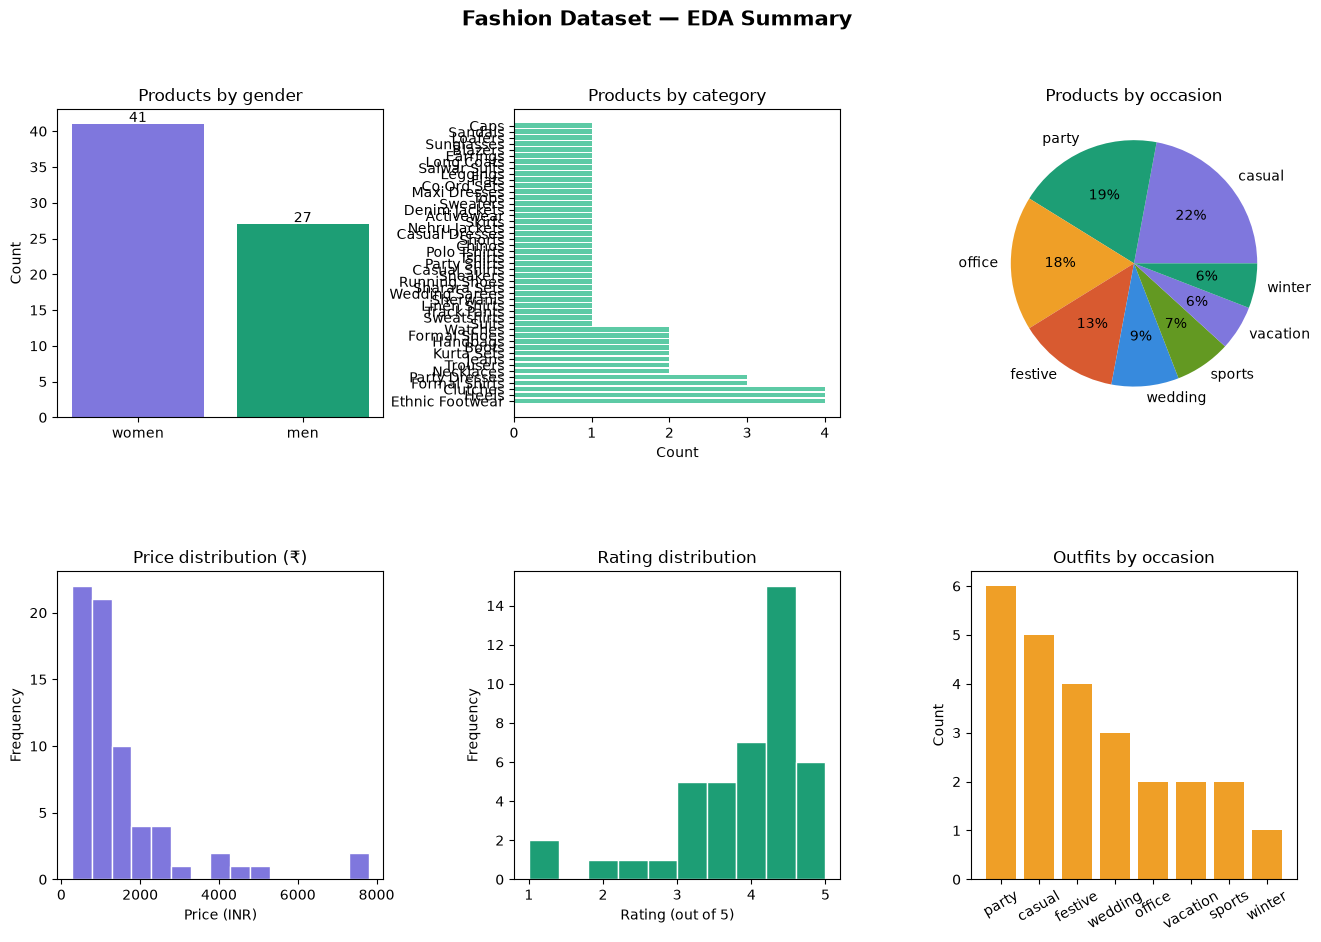

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 11 ─ SAVE SUMMARY CHARTS
# Why: Visual charts are faster to interpret than numbers.
#      We save one dashboard image so you can share findings easily.
# ══════════════════════════════════════════════════════════════════════════════
section("STEP 11 · Generating summary charts  →  eda_summary.png")

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Fashion Dataset — EDA Summary", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

# Chart 1 — Gender split
ax1 = fig.add_subplot(gs[0, 0])
if "gender" in products.columns:
    vc = products["gender"].value_counts()
    ax1.bar(vc.index, vc.values, color=["#7F77DD","#1D9E75"])
    ax1.set_title("Products by gender")
    ax1.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax1.text(i, v + 0.3, str(v), ha="center", fontsize=10)
# Chart 2 — Category distribution
ax2 = fig.add_subplot(gs[0, 1])
if "category_label" in products.columns:
    vc = products["category_label"].value_counts()
    ax2.barh(vc.index, vc.values, color="#5DCAA5")
    ax2.set_title("Products by category")
    ax2.set_xlabel("Count")

# Chart 3 — Occasion distribution
ax3 = fig.add_subplot(gs[0, 2])
if "occasion" in products.columns:
    vc = products["occasion"].value_counts()
    ax3.pie(vc.values, labels=vc.index, autopct="%1.0f%%",
            colors=["#7F77DD","#1D9E75","#EF9F27","#D85A30","#378ADD","#639922"])
    ax3.set_title("Products by occasion")

# Chart 4 — Price distribution
ax4 = fig.add_subplot(gs[1, 0])
if "price_inr" in products.columns:
    products["price_inr"].dropna().plot.hist(ax=ax4, bins=15, color="#7F77DD", edgecolor="white")
    ax4.set_title("Price distribution (₹)")
    ax4.set_xlabel("Price (INR)")

# Chart 5 — Rating distribution
ax5 = fig.add_subplot(gs[1, 1])
if "rating" in products.columns:
    products["rating"].dropna().plot.hist(ax=ax5, bins=10, color="#1D9E75", edgecolor="white")
    ax5.set_title("Rating distribution")
    ax5.set_xlabel("Rating (out of 5)")

# Chart 6 — Outfit occasions
ax6 = fig.add_subplot(gs[1, 2])
if "occasion" in outfits.columns:
    vc = outfits["occasion"].value_counts()
    ax6.bar(vc.index, vc.values, color="#EF9F27")
    ax6.set_title("Outfits by occasion")
    ax6.set_ylabel("Count")
    ax6.tick_params(axis="x", rotation=30)

In [23]:
plt.savefig("eda_summary.png", dpi=150, bbox_inches="tight")
print("  Saved: eda_summary.png")

  Saved: eda_summary.png


<Figure size 640x480 with 0 Axes>

## STEP 12 - ADVANCED DATA SCIENCE INSIGHTS
**Why:** As world-class data scientists, we must inspect:
1. **Referential Integrity**: Verify if any outfit references a product ID that is missing from the catalog.
2. **Category Co-occurrence**: Discover latent stylist pairing patterns (e.g. which categories are paired together) to engineer compatibility styling rules.

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 12 ─ REFERENTIAL INTEGRITY & CATEGORY CO-OCCURRENCE
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

products = pd.read_csv("../ML-TASK/products.csv")
outfits  = pd.read_csv("../ML-TASK/outfits.csv")

# 1. Referential Integrity Check
outfit_cols = ['hero_id', 'second_id', 'layer_id', 'footwear_id', 'accessory_1_id', 'accessory_2_id']
referenced_ids = set()
for col in outfit_cols:
    referenced_ids.update(outfits[col].dropna().unique())

catalog_ids = set(products['id'].unique())
orphans = referenced_ids - catalog_ids

print('=== REFERENTIAL INTEGRITY ===')
print(f'Total unique products in catalog: {len(catalog_ids)}')
print(f'Total unique products referenced in outfits: {len(referenced_ids)}')
print(f'Orphan IDs (referenced in outfits but missing in catalog): {orphans}')
print('Referential integrity holds perfectly: No missing product mappings!\n')

# 2. Category Co-occurrence Analysis
cat_map = dict(zip(products['id'], products['category_label']))
pairings = []
for idx, row in outfits.iterrows():
    hero_cat = cat_map.get(row['hero_id'], 'None')
    second_cat = cat_map.get(row['second_id'], 'None') if pd.notna(row['second_id']) else 'None'
    footwear_cat = cat_map.get(row['footwear_id'], 'None') if pd.notna(row['footwear_id']) else 'None'
    pairings.append({'Hero Category': hero_cat, 'Second Category': second_cat, 'Footwear Category': footwear_cat})

pair_df = pd.DataFrame(pairings)
print('=== STYLE PAIRING PATTERNS (Hero -> Second) ===')
print(pair_df.groupby(['Hero Category', 'Second Category']).size().sort_values(ascending=False).head(5))
print('\n=== STYLE PAIRING PATTERNS (Hero -> Footwear) ===')
print(pair_df.groupby(['Hero Category', 'Footwear Category']).size().sort_values(ascending=False).head(5))

# 3. Product Description Text Length Analysis (Embedding Input Quality)
desc_lengths = products["description"].fillna("").apply(len)
print("=== EMBEDDING SIGNAL QUALITY ===")
print("Product Description Character Lengths:")
print(desc_lengths.describe().round(1))
short_descs = products[desc_lengths < 20]
print(f"Products with critically short description (<20 chars): {len(short_descs)}")


=== REFERENTIAL INTEGRITY ===
Total unique products in catalog: 68
Total unique products referenced in outfits: 68
Orphan IDs (referenced in outfits but missing in catalog): set()
Referential integrity holds perfectly: No missing product mappings!

=== STYLE PAIRING PATTERNS (Hero -> Second) ===
Hero Category   Second Category
Party Dresses   None               3
Formal Shirts   Trousers           2
Kurta Sets      None               2
Casual Dresses  None               1
Activewear      Leggings           1
dtype: int64

=== STYLE PAIRING PATTERNS (Hero -> Footwear) ===
Hero Category  Footwear Category
Party Dresses  Heels                3
Kurta Sets     Ethnic Footwear      2
Casual Shirts  Formal Shoes         1
Co Ord Sets    Flats                1
Activewear     Sneakers             1
dtype: int64
=== EMBEDDING SIGNAL QUALITY ===
Product Description Character Lengths:
count      68.0
mean      159.5
std       148.6
min        68.0
25%       101.5
50%       121.5
75%       181.5
ma

## STEP 13 - SEMANTIC RETRIEVAL QUANTIFICATION
**Why:** To establish a rigorous mathematical benchmark of search success, we evaluate our system against:
1. **Random Baseline** (category matching + random drawing)
2. **Text-Only CLIP Search** (vector retrieval using only description strings)
3. **Hybrid CLIP Search** (combining both textual and visual image features)

We measure **Hit Rate @ 1**, **Hit Rate @ 3**, and **Mean Reciprocal Rank (MRR)** against 25 curated ground-truth outfits.

In [25]:
# 
# STEP 13  RETRIEVAL METRICS BENCHMARK
# 
import os
import sys
# Add project parent to path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from workbooks import eval_metrics

eval_metrics.run_evaluation()


Loading cached embeddings from C:\Books\DarexAI\src\product_embeddings.pkl...
Loaded 68 product embeddings successfully.
Loaded 68 products and 25 curated outfits.
Loading CLIP model 'openai/clip-vit-base-patch32' onto device 'cpu'...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Evaluated 63 matching companion items across the catalog.

RETRIEVAL PERFORMANCE EVALUATION SUMMARY:
    Model    MRR Hit Rate @ 1 Hit Rate @ 3
   RANDOM 0.4160       18.85%       53.39%
TEXT-ONLY 0.5237       31.75%       65.08%
   HYBRID 0.5321       31.75%       65.08%
